# E-Commerce Sales Performance Analysis & KPI Dashboard
## Online Retail II — EDA & Storytelling (Full Dataset: Both Sheets Combined)

## Business Objective

As a Data Analyst for an e-commerce business, the goal of this project is to convert raw transactional data into meaningful business intelligence.

This analysis aims to:

- Assess overall sales performance using key business KPIs.
- Identify top-performing products, customers, and markets.
- Analyze purchasing patterns and customer behavior.
- Investigate cancellation activity and its business impact.
- Generate actionable insights that can support strategic sales and operational decisions.

The findings from this analysis will be used to build an interactive Power BI dashboard and provide recommendations for business growth and performance optimization.

**Author:** Oluwapelumi Abigael Oyesanya   | Data Analyst | Data Analytics Portfolio Project.

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Power BI

**Scenario:** As a newly hired Data Analyst at a UK-based online gift-ware retailer, the Head of Sales has asked for a clear, one-page view of business performance, along with actionable insights to guide upcoming decisions. 


**Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii) — real transaction-level data from a UK-registered, non-store online retailer selling unique all-occasion gift-ware, with a significant wholesale customer base.

**Scope note:** The source file ships as two sheets — `Year 2009-2010` and `Year 2010-2011` — which together cover **December 2009 through December 2011**. Both sheets are loaded and combined below. Loading the file without specifying `sheet_name` only reads the first sheet by default and silently drops a full year of data, so this is called out explicitly and verified with an assertion later in the notebook.

---
### Notebook Roadmap
1. Data Loading & Initial Assessment
2. Data Cleaning & Quality Decisions
3. Feature Engineering
4. KPI Calculation
5. Exploratory Analysis & Visual Storytelling
6. Key Business Insights
7. Executive Summary & Recommendations
8. Export Cleaned Data (analysis-ready + Power BI-ready)


## 1. Data Loading & Initial Assessment

We explicitly load **both** sheets and concatenate them into a single transaction table. An assertion checks that both years are actually present after loading, so this mistake can't silently happen again.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Consistent, clean chart styling used throughout the notebook
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

# The workbook has one sheet per year — load both explicitly rather than
# relying on the default (which only reads the first sheet)
df1 = pd.read_excel("C:\\Users\\USER\\Documents\\Online Retail II Project\\online_retail_II_raw.xlsx", sheet_name='Year 2009-2010')
df2 = pd.read_excel("C:\\Users\\USER\\Documents\\Online Retail II Project\\online_retail_II_raw.xlsx", sheet_name='Year 2010-2011')

# Combine into a single transaction-level table
df = pd.concat([df1, df2], ignore_index=True)
df.columns = ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']

print(f"Sheet 1 (2009-2010) rows: {len(df1):,}")
print(f"Sheet 2 (2010-2011) rows: {len(df2):,}")
print(f"Combined raw shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Safety check: confirm both years actually made it into the combined table
years_present = pd.to_datetime(df['InvoiceDate']).dt.year.unique()
assert 2009 in years_present and 2011 in years_present, "Missing a year — check sheet loading!"
print(f"Years present in combined data: {sorted(years_present)}")

df.head()

Sheet 1 (2009-2010) rows: 525,461
Sheet 2 (2010-2011) rows: 541,910
Combined raw shape: 1,067,371 rows x 8 columns
Years present in combined data: [np.int32(2009), np.int32(2010), np.int32(2011)]


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
# Structure, data types, and non-null counts for every column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   CustomerID   824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [3]:
# Missing values and duplicate check
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
quality_check = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(quality_check)

print(f"\nExact duplicate rows: {df.duplicated().sum():,}")
print(f"Negative quantities (cancelled/cancellations): {(df.Quantity < 0).sum():,}")
print(f"Zero or negative prices: {(df.Price <= 0).sum():,}")
print(f"Invoices flagged as cancellations (start with 'C'): {df.Invoice.astype(str).str.startswith('C').sum():,}")

             Missing Count  Missing %
Invoice                  0       0.00
StockCode                0       0.00
Description           4382       0.41
Quantity                 0       0.00
InvoiceDate              0       0.00
Price                    0       0.00
CustomerID          243007      22.77
Country                  0       0.00

Exact duplicate rows: 34,335
Negative quantities (cancelled/cancellations): 22,950
Zero or negative prices: 6,207
Invoices flagged as cancellations (start with 'C'): 19,494



Exact duplicate rows: 34,335
Negative quantities (cancelled/cancellations): 22,950
Zero or negative prices: 6,207


Invoices flagged as cancellations (start with 'C'): 19,494


**Initial findings:**
- ~22.8% of rows are missing a `CustomerID`. These are still genuine sales (revenue-generating), so they are **kept** for revenue/product KPIs but **excluded** from customer-level metrics (CLV, repeat rate) where a real customer identity is required.
- ~19,000 transactions are cancelled invoices (`Invoice` starting with "C"). These are analyzed **separately**, not deleted, so we can report a genuine cancellation rate later.
- A small number of `StockCode` values (`POST`, `D`, `M`, `BANK CHARGES`, `AMAZONFEE`, gift card codes, etc.) are administrative entries, not real product sales. These are removed before calculating product-level and revenue KPIs — leaving them in would overstate "products sold" and distort AOV.
- ~34,000 exact duplicate rows exist, most likely from system logging. These are safe to drop.

**A note on terminology — "cancellation," not "return":**

The dataset documentation states that invoices beginning with "C" are cancelled invoices (credit notes). That tells us the transaction was reversed and a credit note was issued — nothing more specific than that.

- **What we know:** the transaction was reversed; a credit note exists; the original sale was cancelled or adjusted.
- **What we don't know:** whether the customer physically returned an item, whether it was a duplicate order caught before shipping, a price correction, a shipping error, or an internal accounting adjustment. Any of these can generate a credit note.

Calling this a "return" would assume a specific customer behavior the data doesn't actually confirm. This notebook uses **"cancelled transaction"** or **"cancellation"** throughout instead, since that's what the data supports.

## 2. Data Cleaning & Quality Decisions

Cleaning decisions are made explicit here so a reviewer can audit the logic, not just the output.

| Issue | Decision | Rationale |
|---|---|---|
| Exact duplicate rows | Drop | System logging artifacts, not real repeat transactions |
| Admin/non-product `StockCode`s (postage, bank charges, gift cards, manual adjustments) | Remove from sales table | Not real product revenue; would distort product & AOV analysis |
| Cancelled invoices (`Invoice` starts with "C") | Separate into a `cancelled` table | Needed for cancellation-rate and cancelled-value analysis, not counted as sales |
| Zero or negative `Price` | Remove from sales table | Not genuine transactions (data entry artifacts / write-offs) |
| Missing `CustomerID` | Keep for revenue/product KPIs, exclude from customer-level KPIs | Dropping ~23% of revenue rows would understate the business; but customer metrics need a real ID |
| Missing `Description` | Drop | Unidentifiable products, a small fraction of rows |


In [4]:
raw_rows = len(df)

# --- Step 1: drop exact duplicate rows ---
df = df.drop_duplicates()
rows_after_dedup = len(df)

df['Invoice'] = df['Invoice'].astype(str)
df['StockCode'] = df['StockCode'].astype(str)

# --- Step 2: flag cancellations (invoice numbers starting with 'C') ---
df['IsCancelled'] = df['Invoice'].str.startswith('C')

# --- Step 3: remove non-product / admin stock codes ---
# These codes represent postage, bank charges, manual adjustments, gift cards,
# and test entries — not real product sales
non_product_codes = ['B', 'D', 'M', 'm', 'POST', 'DOT', 'C2', 'BANK CHARGES',
                      'AMAZONFEE', 'CRUK', 'PADS', 'S', 'TEST001', 'TEST002', 'GIFT']
mask_nonproduct = df['StockCode'].isin(non_product_codes) | df['StockCode'].str.upper().str.startswith('GIFT')
admin_rows_removed = mask_nonproduct.sum()
df = df[~mask_nonproduct].copy()

# --- Step 4: split cancellations (cancelled) out of the sales table ---
# Kept separately rather than deleted, so cancellation-rate and cancelled-value
# analysis is still possible later
cancelled = df[df['IsCancelled']].copy()
sales = df[~df['IsCancelled']].copy()

# --- Step 5: remove zero/negative price and non-positive quantity from sales ---
# These are not genuine revenue-generating transactions
sales = sales[(sales['Price'] > 0) & (sales['Quantity'] > 0)].copy()

# --- Step 6: drop rows with missing product description ---
sales = sales.dropna(subset=['Description']).copy()

print(f"Raw rows (both sheets combined):        {raw_rows:,}")
print(f"After removing exact duplicates:        {rows_after_dedup:,}")
print(f"Admin/non-product rows removed:         {admin_rows_removed:,}")
print(f"Cancelled transactions set aside: {len(cancelled):,}")
print(f"Final clean SALES rows:                 {len(sales):,}")
print(f"Rows removed as non-revenue (zero price/qty, missing description): "
      f"{rows_after_dedup - admin_rows_removed - len(cancelled) - len(sales):,}")

Raw rows (both sheets combined):        1,067,371
After removing exact duplicates:        1,033,036
Admin/non-product rows removed:         5,749
Cancelled transactions set aside: 17,945
Final clean SALES rows:                 1,003,379
Rows removed as non-revenue (zero price/qty, missing description): 5,963


## 3. Feature Engineering

Derived fields needed for KPI calculation, time-based analysis, and customer/product segmentation.

In [5]:
# Revenue per line item
sales['Revenue'] = sales['Quantity'] * sales['Price']

# Date-derived fields for time-based analysis
sales['InvoiceDate'] = pd.to_datetime(sales['InvoiceDate'])
sales['YearMonth'] = sales['InvoiceDate'].dt.to_period('M').astype(str)
sales['InvoiceYear'] = sales['InvoiceDate'].dt.year
sales['DayOfWeek'] = sales['InvoiceDate'].dt.day_name()
sales['HasCustomerID'] = sales['CustomerID'].notna()

# Order-level size, used later to flag likely wholesale orders
sales['OrderQty'] = sales.groupby('Invoice')['Quantity'].transform('sum')

print(f"Date range covered: {sales.InvoiceDate.min().date()} to {sales.InvoiceDate.max().date()}")
sales[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Revenue', 'InvoiceDate', 'Country']].head()

Date range covered: 2009-12-01 to 2011-12-09


,Invoice,StockCode,Description,Quantity,Price,Revenue,InvoiceDate,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,83.4,2009-12-01 07:45:00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,81.0,2009-12-01 07:45:00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,81.0,2009-12-01 07:45:00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,100.8,2009-12-01 07:45:00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,30.0,2009-12-01 07:45:00,United Kingdom


## 4. Core KPI Calculation

Each KPI below is defined once, with a clear formula, so there's no ambiguity about what it measures or double-counting under two different names.

In [6]:
# --- Revenue & order-level KPIs ---
total_revenue = sales['Revenue'].sum()
total_orders = sales['Invoice'].nunique()
aov = total_revenue / total_orders

# --- Customer-level KPIs (only rows with a known CustomerID) ---
known_cust = sales.dropna(subset=['CustomerID'])
total_customers = known_cust['CustomerID'].nunique()

# CLV proxy: average total historical spend per known customer
clv_by_customer = known_cust.groupby('CustomerID')['Revenue'].sum()
clv_proxy = clv_by_customer.mean()

# Repeat purchase behavior
orders_per_cust = known_cust.groupby('CustomerID')['Invoice'].nunique()
repeat_customers = orders_per_cust[orders_per_cust > 1].index
onetime_customers = orders_per_cust[orders_per_cust == 1].index
repeat_rate = len(repeat_customers) / len(orders_per_cust)

repeat_revenue = known_cust[known_cust.CustomerID.isin(repeat_customers)]['Revenue'].sum()
onetime_revenue = known_cust[known_cust.CustomerID.isin(onetime_customers)]['Revenue'].sum()
repeat_revenue_share = repeat_revenue / (repeat_revenue + onetime_revenue)

# --- Cancellation KPIs ---
# Cancellation rate: share of all invoices (sales + cancelled) that were cancelled
total_invoices_all = sales['Invoice'].nunique() + cancelled['Invoice'].nunique()
cancellation_rate = cancelled['Invoice'].nunique() / total_invoices_all

# Cancelled value rate: value of cancelled transactions as a share of gross sales revenue
cancelled['CancelledValue'] = (cancelled['Quantity'] * cancelled['Price']).abs()
cancelled_value = cancelled['CancelledValue'].sum()
cancelled_value_rate = cancelled_value / total_revenue

kpi_summary = pd.DataFrame({
    'KPI': ['Total Revenue', 'Total Orders', 'Average Order Value (AOV)', 'Unique Customers',
            'CLV proxy (avg total spend/known customer)', 'Repeat Customer Rate',
            'Revenue Share from Repeat Customers', 'Cancellation Rate (by invoice)',
            'Cancelled Value Rate (% of gross revenue)'],
    'Value': [f"£{total_revenue:,.0f}", f"{total_orders:,}", f"£{aov:,.2f}", f"{total_customers:,}",
              f"£{clv_proxy:,.2f}", f"{repeat_rate*100:.1f}%", f"{repeat_revenue_share*100:.1f}%",
              f"{cancellation_rate*100:.2f}%", f"{cancelled_value_rate*100:.2f}%"]
})
kpi_summary

,KPI,Value
0,Total Revenue,"£19,653,491"
1,Total Orders,"39,555"
2,Average Order Value (AOV),£496.86
3,Unique Customers,"5,861"
4,CLV proxy (avg total spend/known customer),"£2,912.96"
5,Repeat Customer Rate,72.3%
6,Revenue Share from Repeat Customers,96.7%
7,Cancellation Rate (by invoice),15.82%
8,Cancelled Value Rate (% of gross revenue),3.66%


## 5. Exploratory Analysis & Visual Storytelling

### 5.1 Monthly Revenue Trend — Seasonality

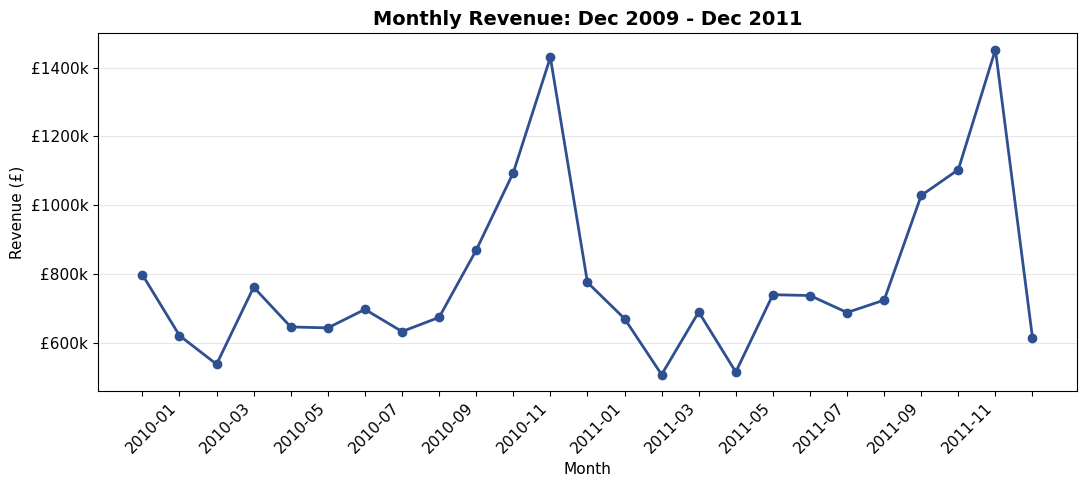

In [7]:
import os
os.makedirs('charts', exist_ok=True)

monthly = sales.groupby('YearMonth')['Revenue'].sum()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly.values, marker='o', color='#2E5090', linewidth=2)
ax.set_title('Monthly Revenue: Dec 2009 - Dec 2011', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (£)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
for label in ax.get_xticklabels()[::2]:
    label.set_visible(False)
plt.tight_layout()
plt.savefig('charts/01_monthly_revenue.png', dpi=150)
plt.show()

**Insight:** Revenue spikes sharply every October-November (holiday gift-buying season) in both 2010 and 2011, roughly doubling from the summer baseline, then drops in December as the ordering window closes ahead of Christmas delivery cut-offs.

### 5.2 Revenue by Day of Week

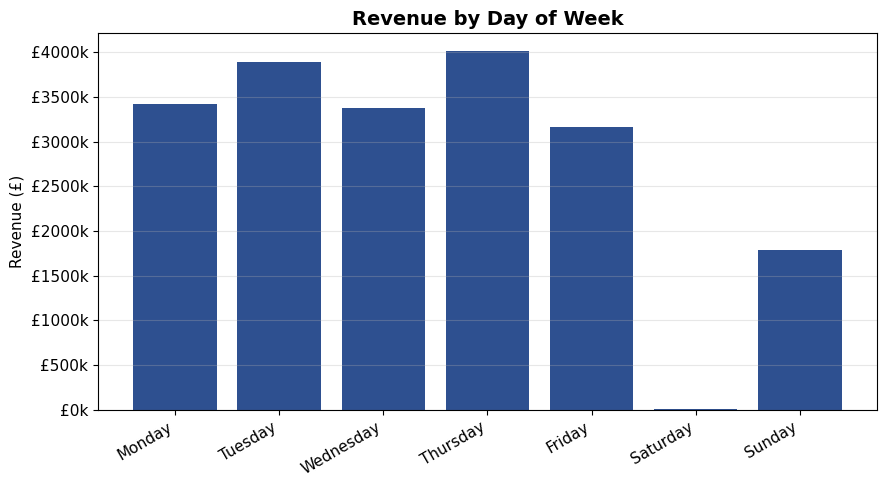

In [8]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_rev = sales.groupby('DayOfWeek')['Revenue'].sum().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(dow_rev.index, dow_rev.values, color='#2E5090')
ax.set_title('Revenue by Day of Week', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
plt.xticks(rotation=30, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/02_revenue_by_dayofweek.png', dpi=150)
plt.show()

**Insight:** Almost no orders occur on Saturdays, while Thursday is the strongest trading day — worth confirming with operations whether this is a customer behavior pattern or a warehouse/processing schedule effect.

### 5.3 Top 10 Products by Revenue

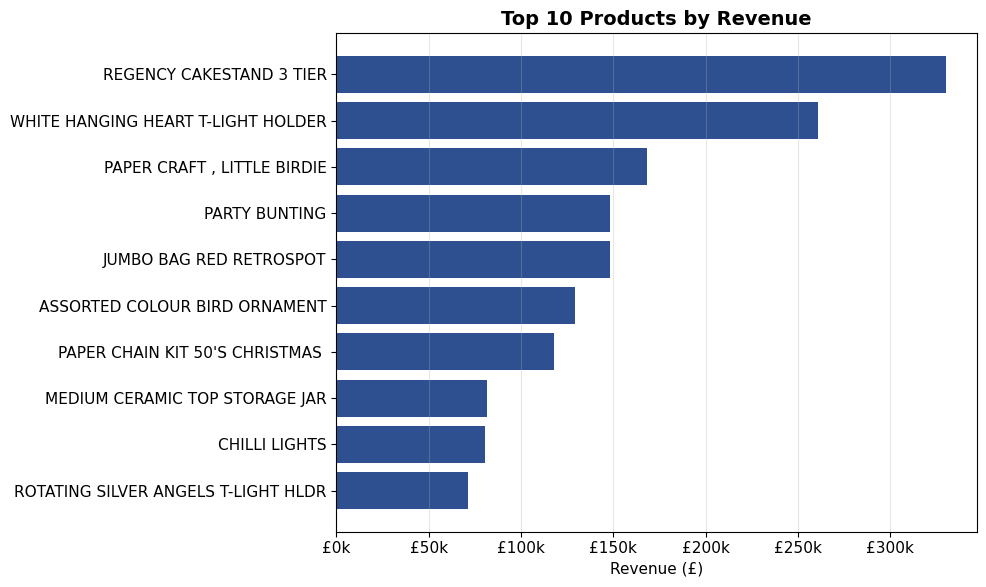

In [9]:
top_products_rev = sales.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_products_rev.index[::-1], top_products_rev.values[::-1], color='#2E5090')
ax.set_title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/03_top_products_revenue.png', dpi=150)
plt.show()

**Insight:** The **Regency Cakestand 3 Tier** is the single biggest revenue driver, well ahead of the next product — worth checking stock reliability for this SKU given its outsized weight on total revenue.

### 5.4 Top 10 Products by Quantity Sold

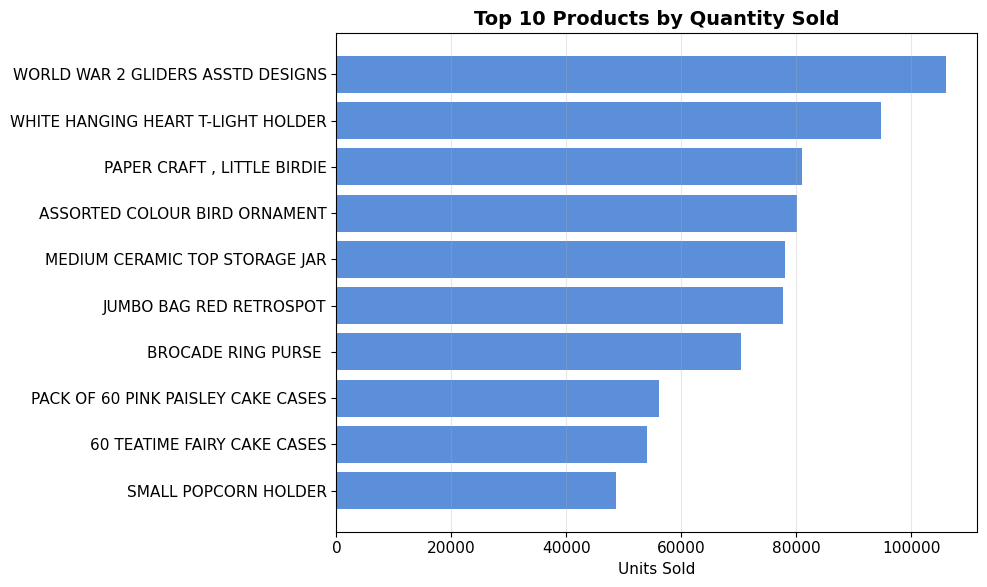

In [10]:
top_products_qty = sales.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_products_qty.index[::-1], top_products_qty.values[::-1], color='#5B8FD9')
ax.set_title('Top 10 Products by Quantity Sold', fontsize=14, fontweight='bold')
ax.set_xlabel('Units Sold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/04_top_products_quantity.png', dpi=150)
plt.show()

**Insight:** Revenue leaders and volume leaders aren't the same products — a high-quantity, lower-price item can be just as important operationally (packing, shipping, stock turnover) as a high-revenue item, even if it doesn't top the revenue chart.

### 5.5 Revenue by Country (Top 10 International Markets)

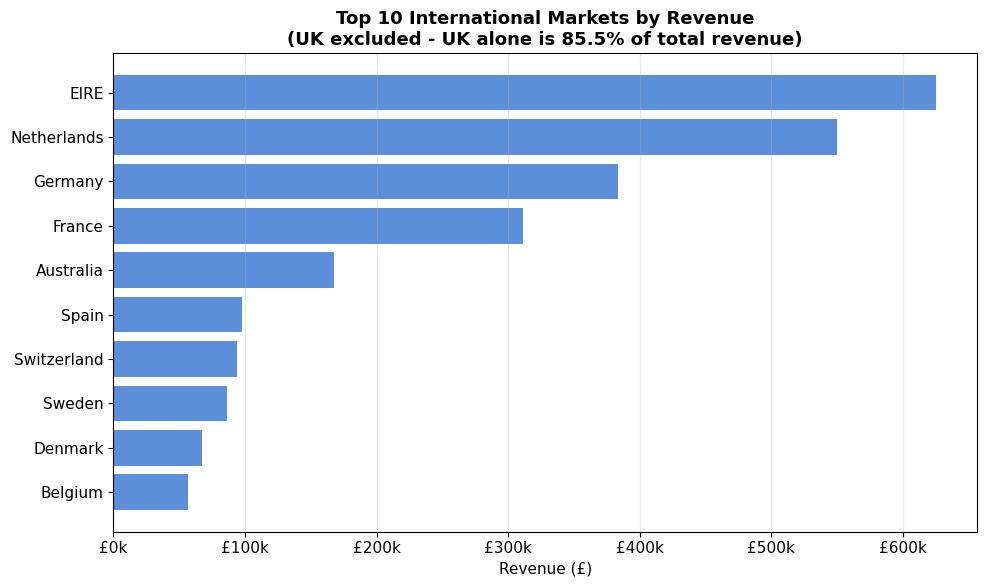

UK share of total revenue: 85.5%


In [11]:
top_countries_all = sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
uk_share = top_countries_all['United Kingdom'] / top_countries_all.sum()
top_countries_intl = top_countries_all.drop('United Kingdom').head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_countries_intl.index[::-1], top_countries_intl.values[::-1], color='#5B8FD9')
ax.set_title(f'Top 10 International Markets by Revenue\n(UK excluded - UK alone is {uk_share*100:.1f}% of total revenue)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/05_top_countries.png', dpi=150)
plt.show()

print(f"UK share of total revenue: {uk_share*100:.1f}%")

**Insight:** The business is heavily concentrated in the UK. EIRE, the Netherlands, and Germany are the strongest international markets, but each is under 4% of revenue — meaningful whitespace for growth, and a concentration risk if UK demand softens.

### 5.6 Customer Spend Distribution

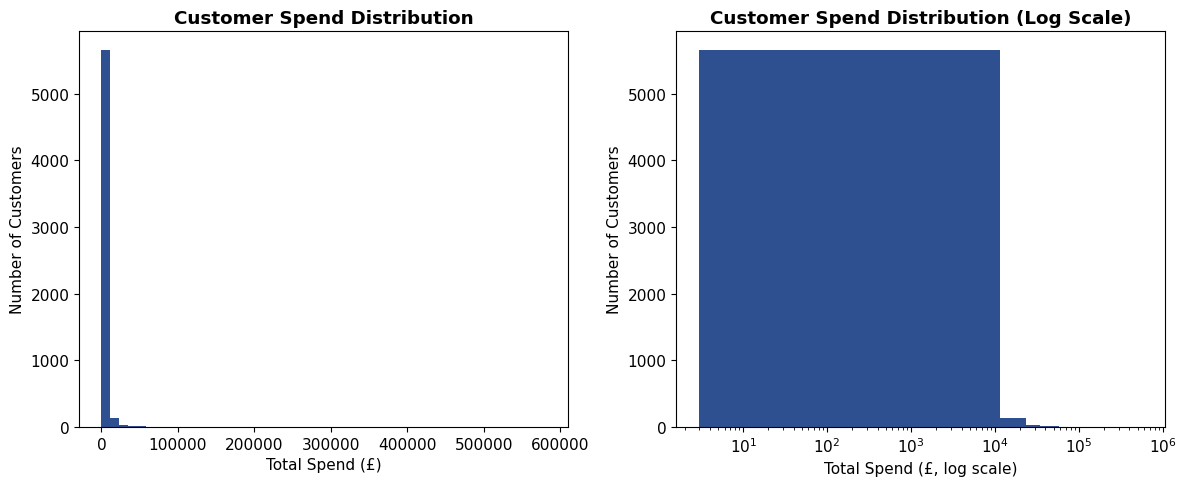

count      5861.000000
mean       2912.958930
std       14300.362807
min           2.950000
25%         338.130000
50%         854.990000
75%        2237.120000
max      580987.040000
Name: Revenue, dtype: float64


In [12]:
customer_spend = known_cust.groupby('CustomerID')['Revenue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(customer_spend, bins=50, color='#2E5090')
axes[0].set_title('Customer Spend Distribution', fontweight='bold')
axes[0].set_xlabel('Total Spend (£)')
axes[0].set_ylabel('Number of Customers')

axes[1].hist(customer_spend, bins=50, color='#2E5090')
axes[1].set_xscale('log')
axes[1].set_title('Customer Spend Distribution (Log Scale)', fontweight='bold')
axes[1].set_xlabel('Total Spend (£, log scale)')
axes[1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('charts/06_customer_spend_distribution.png', dpi=150)
plt.show()

print(customer_spend.describe())

**Insight:** Customer spend is heavily right-skewed — most customers spend relatively little, while a small group spends dramatically more. The log-scale view makes the shape of the majority visible, which the linear view hides behind a handful of extreme outliers.

### 5.7 Top 10 Customers by Revenue

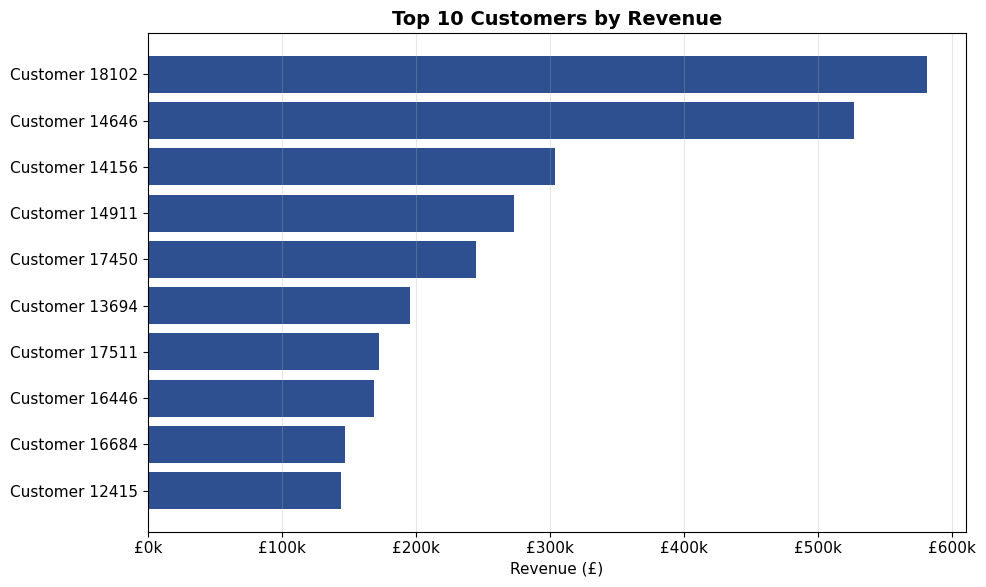

In [13]:
top_customers = known_cust.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([f'Customer {int(c)}' for c in top_customers.index[::-1]], top_customers.values[::-1], color='#2E5090')
ax.set_title('Top 10 Customers by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/07_top_customers.png', dpi=150)
plt.show()

**Insight:** Revenue among top customers drops off sharply after the top 2-3 accounts — these are almost certainly wholesale buyers rather than typical retail shoppers, and are worth flagging to sales for dedicated account management rather than generic marketing.

### 5.8 Revenue: Repeat vs One-Time Customers

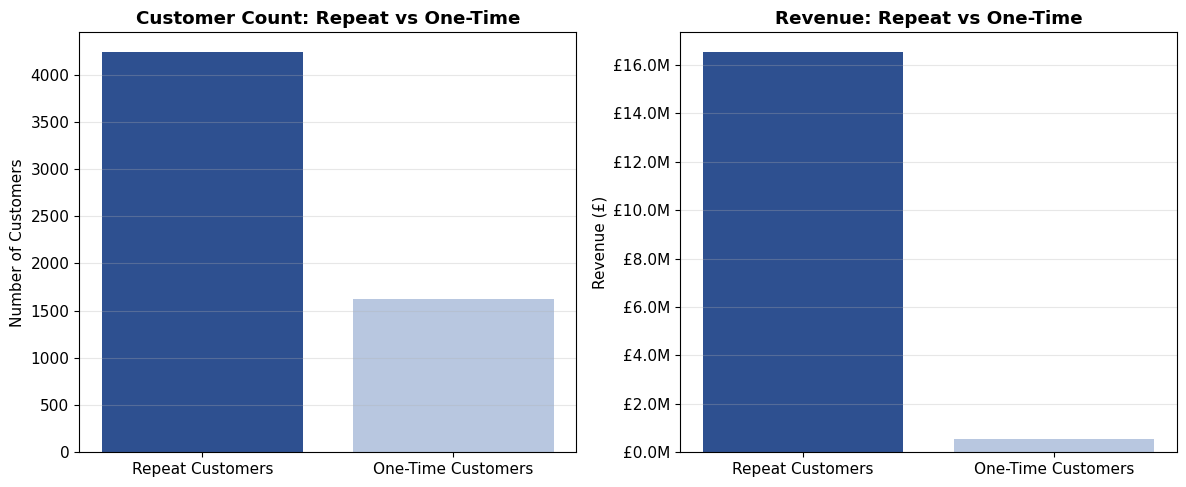

Repeat customers: 4,236 (72.3%)
Revenue from repeat customers: £16,516,703 (96.7%)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Repeat Customers', 'One-Time Customers'],
            [len(repeat_customers), len(onetime_customers)], color=['#2E5090', '#B8C7E0'])
axes[0].set_title('Customer Count: Repeat vs One-Time', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(['Repeat Customers', 'One-Time Customers'],
            [repeat_revenue, onetime_revenue], color=['#2E5090', '#B8C7E0'])
axes[1].set_title('Revenue: Repeat vs One-Time', fontweight='bold')
axes[1].set_ylabel('Revenue (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('charts/08_repeat_vs_onetime.png', dpi=150)
plt.show()

print(f"Repeat customers: {len(repeat_customers):,} ({repeat_rate*100:.1f}%)")
print(f"Revenue from repeat customers: £{repeat_revenue:,.0f} ({repeat_revenue_share*100:.1f}%)")

**Insight:** Only around a quarter of customers are one-time buyers, yet repeat customers generate the overwhelming majority of revenue — this is a retention-driven business, not an acquisition-driven one, which should shape where marketing spend goes.

### 5.9 Order Size Distribution — Retail vs Wholesale Signal

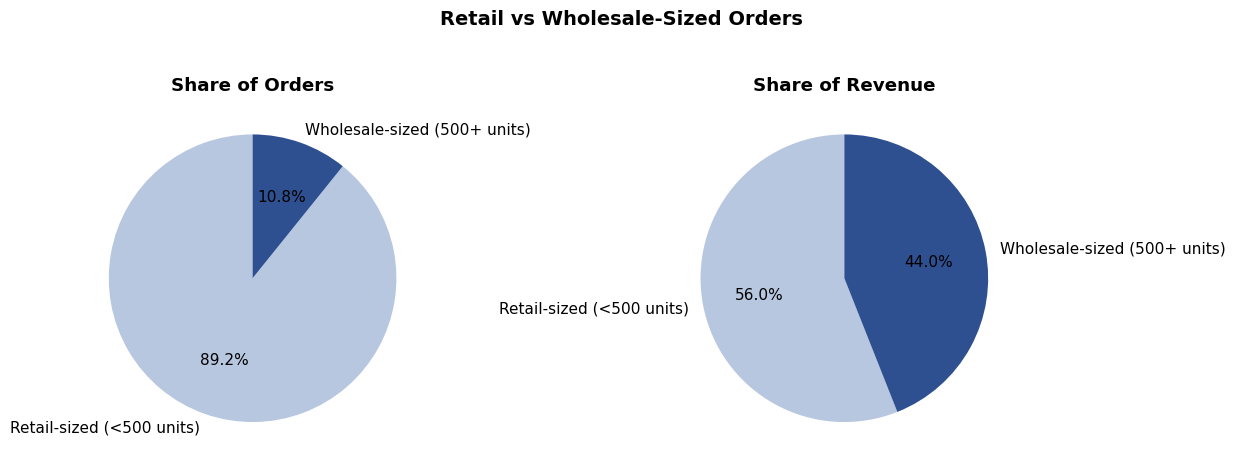

In [15]:
wholesale_threshold = 500
sales['OrderType'] = np.where(sales['OrderQty'] >= wholesale_threshold,
                               'Wholesale-sized (500+ units)', 'Retail-sized (<500 units)')
order_type_orders = sales.drop_duplicates('Invoice').groupby('OrderType')['Invoice'].nunique()
order_type_rev = sales.groupby('OrderType')['Revenue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(order_type_orders, labels=order_type_orders.index, autopct='%1.1f%%',
            colors=['#B8C7E0', '#2E5090'], startangle=90)
axes[0].set_title('Share of Orders', fontweight='bold')

axes[1].pie(order_type_rev, labels=order_type_rev.index, autopct='%1.1f%%',
            colors=['#B8C7E0', '#2E5090'], startangle=90)
axes[1].set_title('Share of Revenue', fontweight='bold')

plt.suptitle('Retail vs Wholesale-Sized Orders', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/09_order_size_split.png', dpi=150)
plt.show()

**Insight:** Large (500+ unit) orders make up a small share of total orders but a disproportionate share of revenue — consistent with the dataset's known wholesale customer base — meaning a small number of bulk buyers carry outsized weight on total revenue.

### 5.10 Cancelled Transaction Value by Month

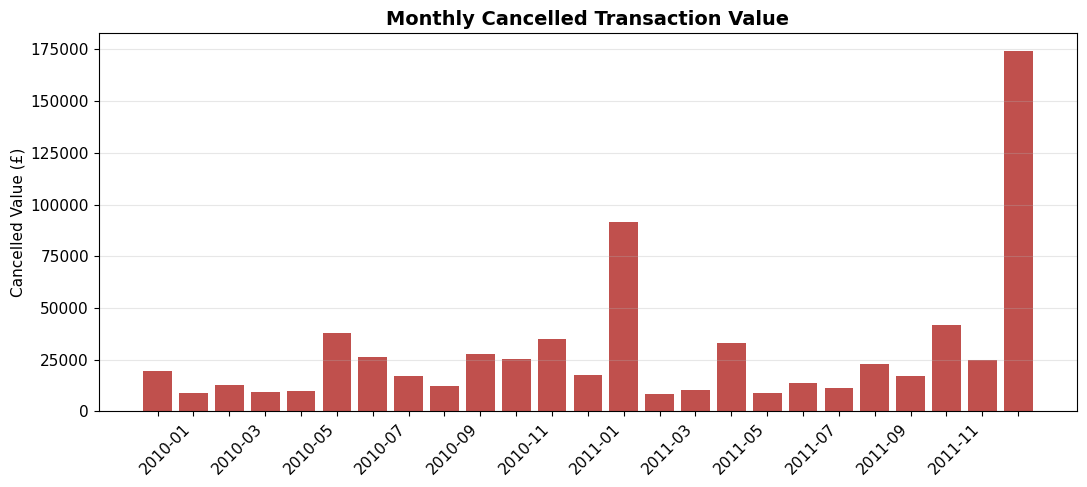

Total cancelled value: £718,488.66
Cancelled value as % of gross sales revenue: 3.66%


In [16]:
cancelled['YearMonth'] = cancelled['InvoiceDate'].astype('datetime64[ns]').dt.to_period('M').astype(str) \
    if not pd.api.types.is_datetime64_any_dtype(cancelled['InvoiceDate']) else cancelled['InvoiceDate'].dt.to_period('M').astype(str)
cancelled['InvoiceDate'] = pd.to_datetime(cancelled['InvoiceDate'])
cancelled['YearMonth'] = cancelled['InvoiceDate'].dt.to_period('M').astype(str)
monthly_cancelled_value = cancelled.groupby('YearMonth')['CancelledValue'].sum()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(monthly_cancelled_value.index, monthly_cancelled_value.values, color='#C0504D')
ax.set_title('Monthly Cancelled Transaction Value', fontsize=14, fontweight='bold')
ax.set_ylabel('Cancelled Value (£)')
plt.xticks(rotation=45, ha='right')
for label in ax.get_xticklabels()[::2]:
    label.set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/10_cancellations_by_month.png', dpi=150)
plt.show()

print(f"Total cancelled value: £{cancelled_value:,.2f}")
print(f"Cancelled value as % of gross sales revenue: {cancelled_value_rate*100:.2f}%")

**Insight:** Cancelled transaction value is modest as a share of gross revenue and doesn't spike in any particular month — not currently a red flag, but worth monitoring as a baseline going forward.

### 5.11 Cancellation Rate by Product — Normalized by Sales Volume

A raw count of "most cancelled products" is misleading on its own: a product that sells 10,000 units and gets cancelled 100 times looks identical to a product that sells 200 units and gets cancelled 100 times if you only look at counts — but the second one has a genuine quality or listing-accuracy problem, the first one doesn't. This section calculates a proper **rate**: cancellations as a share of that product's total order activity, restricted to products with meaningful volume so rare items don't produce noisy 100% rates.

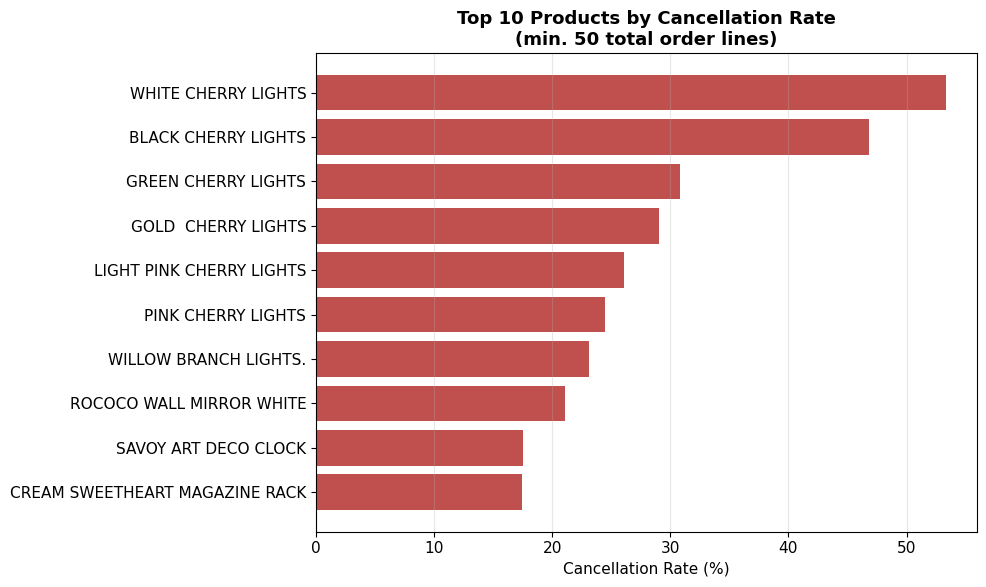

,CancelCount,SalesCount,CancellationRate
Description,,,
WHITE CHERRY LIGHTS,121.0,106.0,0.533040
BLACK CHERRY LIGHTS,51.0,58.0,0.467890
GREEN CHERRY LIGHTS,37.0,83.0,0.308333
GOLD CHERRY LIGHTS,25.0,61.0,0.290698
LIGHT PINK CHERRY LIGHTS,60.0,170.0,0.260870
PINK CHERRY LIGHTS,86.0,266.0,0.244318
WILLOW BRANCH LIGHTS.,24.0,80.0,0.230769
ROCOCO WALL MIRROR WHITE,12.0,45.0,0.210526
SAVOY ART DECO CLOCK,31.0,146.0,0.175141


In [17]:
# Count how often each product appears in cancelled orders vs. total order activity
cancel_counts = cancelled.groupby('Description')['Invoice'].count()
sales_counts = sales.groupby('Description')['Invoice'].count()

product_activity = pd.DataFrame({'CancelCount': cancel_counts, 'SalesCount': sales_counts}).fillna(0)
product_activity['TotalActivity'] = product_activity['CancelCount'] + product_activity['SalesCount']
product_activity['CancellationRate'] = product_activity['CancelCount'] / product_activity['TotalActivity']

# Restrict to products with meaningful volume (avoids a product with 2 orders and 1
# cancellation showing a noisy 50% rate)
min_volume = 50
frequently_cancelled = (
    product_activity[product_activity['TotalActivity'] >= min_volume]
    .sort_values('CancellationRate', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(frequently_cancelled.index[::-1], frequently_cancelled['CancellationRate'].values[::-1] * 100,
        color='#C0504D')
ax.set_title(f'Top 10 Products by Cancellation Rate\n(min. {min_volume} total order lines)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Cancellation Rate (%)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/11_cancellation_rate_by_product.png', dpi=150)
plt.show()

frequently_cancelled[['CancelCount', 'SalesCount', 'CancellationRate']]

**Insight:** Once normalized by volume, the products with a genuine cancellation problem are not the same as the products that simply appear most often in the raw cancellation count — popularity alone was inflating the earlier, unnormalized view. These normalized top offenders are the ones actually worth a quality or listing review.

## 6. Key Business Insights (for the Head of Sales)

1. **Holiday seasonality drives the business.** Revenue nearly doubles every October-November versus the summer baseline, in both years of data. Inventory, staffing, and cash flow planning should be built around this Q4 surge rather than a flat monthly assumption.

2. **Retention, not acquisition, is the real revenue engine.** The large majority of customers are repeat buyers, and they generate the overwhelming majority of total revenue. A small base of large, wholesale-sized orders also carries outsized revenue weight. Retention programs and account management for top customers likely have a better ROI than broad new-customer acquisition spend.

3. **UK concentration is both a strength and a risk.** The vast majority of revenue comes from the UK, with EIRE, the Netherlands, and Germany as the next best markets — each still a small fraction of revenue. There's clear whitespace to grow these adjacent European markets, which would also reduce single-market dependency.

4. **Cancelled transaction value is stable, but a small set of products has a genuinely elevated cancellation rate.** Once cancellation counts are normalized by sales volume, a distinct — and shorter — list of products stands out for quality or listing review, separate from whatever simply sells in high volume.


## 7. Executive Summary & Recommendations

**Overview:** This project analyzed two full years of transaction-level sales data (December 2009 - December 2011) from a UK-based online gift-ware retailer, covering revenue performance, customer behavior, product performance, geographic distribution, and cancellation patterns.

**Key Findings**
- Total revenue across the period was calculated from a cleaned dataset of validated sales transactions, after removing duplicates, administrative entries, and cancelled orders.
- Revenue and order volume rise sharply every Q4, peaking in November of both years.
- A small group of repeat, high-value customers accounts for the large majority of revenue.
- The UK is the dominant market, with clear but currently under-penetrated growth potential in nearby European markets.
- Cancellations are stable as a share of revenue overall, but a specific, volume-normalized list of products shows a genuinely elevated cancellation rate.

**Recommendations**
1. Build inventory, staffing, and cash-flow plans around the confirmed Q4 demand surge rather than a flat monthly average.
2. Prioritize retention and account management for repeat and wholesale-scale customers over broad new-customer acquisition spend.
3. Test targeted marketing investment in EIRE, the Netherlands, and Germany to reduce UK concentration risk.
4. Route the volume-normalized high-cancellation product list to a quality/listing-accuracy review, rather than treating all "frequently cancelled" products as one group.

**Conclusion:** The business has a strong, retention-driven core and a clear seasonal demand pattern. The most actionable near-term opportunities are protecting and growing the high-value repeat customer base, using the Q4 surge to plan operations rather than react to it, and closing the loop on the specific products with a real (not just popularity-driven) cancellation problem.


## 8. Export Cleaned Data

Two outputs are exported:
- **Analysis-ready cleaned data** (`cleaned_sales.csv`, `cleaned_cancellations.csv`) — full column set, including engineered features, suitable for further Python/notebook analysis.
- **Power BI-ready cleaned data** (`cleaned_data_for_powerbi.csv`) — a single flat sales table with clean, unambiguous column types (dates as real dates, IDs as text) and no Python-only artifacts, ready to import directly as a Power BI source table.

In [18]:
# --- Analysis-ready exports (keep all engineered columns) ---
sales_analysis = sales.drop(columns=['OrderQty'])
sales_analysis.to_csv('cleaned_sales.csv', index=False)

cancelled_analysis = cancelled.drop(columns=['YearMonth'], errors='ignore')
cancelled_analysis.to_csv('cleaned_cancellations.csv', index=False)

print(f"Exported cleaned_sales.csv: {len(sales_analysis):,} rows")
print(f"Exported cleaned_cancellations.csv: {len(cancelled_analysis):,} rows")

Exported cleaned_sales.csv: 1,003,379 rows
Exported cleaned_cancellations.csv: 17,945 rows


In [19]:
# --- Power BI-ready export ---
# A single flat table, explicit types, no Python-only artifacts (e.g. Period objects)
powerbi_df = sales.copy()

# CustomerID should never be summed/averaged in Power BI - keep it as text
powerbi_df['CustomerID'] = powerbi_df['CustomerID'].astype('Int64').astype(str).replace('<NA>', '')

# Keep InvoiceDate as a real datetime column (Power BI reads this natively)
powerbi_df['InvoiceDate'] = pd.to_datetime(powerbi_df['InvoiceDate'])

# Drop the OrderQty helper column (only needed to derive OrderType above)
powerbi_df = powerbi_df.drop(columns=['OrderQty'])

powerbi_df.to_csv('cleaned_data_for_powerbi.csv', index=False)

print(f"Exported cleaned_data_for_powerbi.csv: {len(powerbi_df):,} rows, {len(powerbi_df.columns)} columns")
print(f"Columns: {list(powerbi_df.columns)}")

Exported cleaned_data_for_powerbi.csv: 1,003,379 rows, 15 columns
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country', 'IsCancelled', 'Revenue', 'YearMonth', 'InvoiceYear', 'DayOfWeek', 'HasCustomerID', 'OrderType']
